# 01 — Breathing rate from CSI: DSP baseline

**Goal of this notebook.** Take a single recording where the subject was paced at 12 breaths per minute, run a classical signal-processing pipeline on the Wi-Fi CSI, and check whether we recover ~12 BPM. No machine learning yet.

**Why this first.** If the breathing modulation is not recoverable by DSP from a clean, paced recording, then any learned model is going to struggle for reasons that have nothing to do with the model. This notebook is a sanity check on the *data*.

**Inputs**
- `Breathing - 12 BPM - CSI.csv` — ESP32-style CSI export. Each row is one packet; the `CSI_DATA` column is a string of signed bytes encoding complex per-subcarrier channel response.
- `Breathing - Belt & HR.csv` — chest belt + HR ground truth at 50 Hz.

**Pipeline**
1. Parse both files, build CSI amplitude matrix `(time, subcarrier)`.
2. Resample CSI onto a uniform time grid (CSI packet timing is jittery).
3. Per-subcarrier: detrend → bandpass to the breathing band (0.1–0.5 Hz).
4. Pick the subcarriers with the most in-band energy and fuse them.
5. FFT → read the dominant frequency → BPM.
6. Compare to the belt-derived BPM. Target: within ±1 of 12.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path

DATA_DIR = Path('../datasets/Sleep Disturbances Dataset/Vital Signs')
CSI_PATH  = DATA_DIR / 'Breathing - 12 BPM - CSI.csv'
BELT_PATH = DATA_DIR / 'Breathing - Belt & HR.csv'

assert CSI_PATH.exists() and BELT_PATH.exists(), 'check DATA_DIR'

## 1. Load belt ground truth

Belt CSV is sampled at 50 Hz. The `Time` column is formatted like `'0:0:0.04` (note the leading apostrophe — Excel artifact). `Arb1` and `Arb2` are the two analog channels recorded by the Neulog logger; one is the chest-belt strain, the other is HR. We'll plot both and pick the breathing one by eye on the first pass.

In [2]:
belt = pd.read_csv(BELT_PATH)
belt.columns = [c.strip() for c in belt.columns]

# The Neulog export is messy: trailer rows ("Attention! ...", "dot_sign.",
# "coma_sign;"), NaN rows, and a "sys info:[...]" metadata row. Real time
# rows look like "'0:0:0.04" — exactly two colons. Filter on that.
def is_valid_time(v):
    return isinstance(v, str) and v.count(':') == 2

n_before = len(belt)
belt = belt[belt['Time'].map(is_valid_time)].reset_index(drop=True)
print(f'dropped {n_before - len(belt)} non-data rows')

def parse_belt_time(s):
    s = s.lstrip("'")
    h, m, rest = s.split(':')
    return int(h) * 3600 + int(m) * 60 + float(rest)

belt['t'] = belt['Time'].map(parse_belt_time)
belt['Arb1'] = pd.to_numeric(belt['Arb1'], errors='coerce')
belt['Arb2'] = pd.to_numeric(belt['Arb2'], errors='coerce')
belt = belt.dropna(subset=['Arb1', 'Arb2']).reset_index(drop=True)

belt_fs = 1.0 / np.median(np.diff(belt['t']))
print(f'belt rows: {len(belt)}  duration: {belt["t"].iloc[-1]:.1f}s  fs ≈ {belt_fs:.2f} Hz')
belt.head()

dropped 6 non-data rows
belt rows: 15001  duration: 300.0s  fs ≈ 50.00 Hz


,Time,Arb1,Arb2,t
0,'0:0:0.0,71.0,390.0,0.00
1,'0:0:0.02,71.0,387.0,0.02
2,'0:0:0.04,71.0,384.0,0.04
3,'0:0:0.06,71.0,381.0,0.06
4,'0:0:0.08,71.0,378.0,0.08


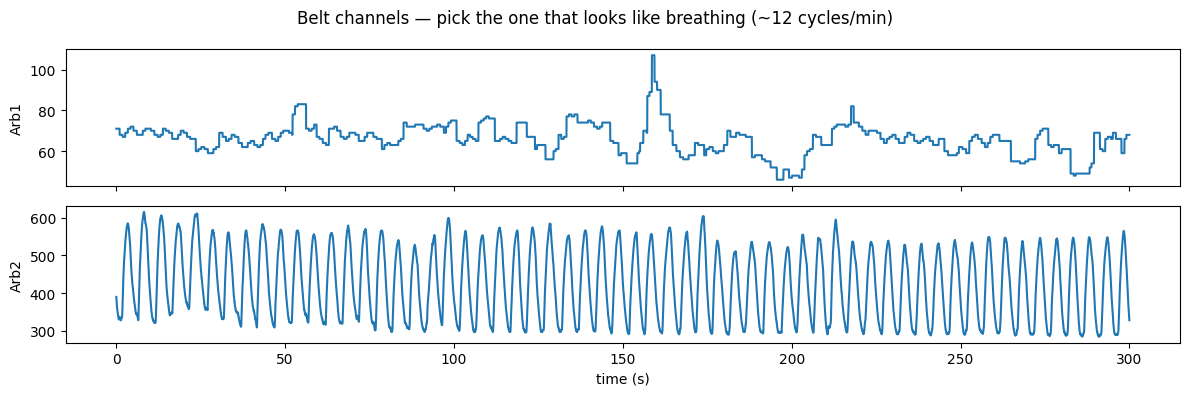

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(belt['t'], belt['Arb1']); axes[0].set_ylabel('Arb1')
axes[1].plot(belt['t'], belt['Arb2']); axes[1].set_ylabel('Arb2'); axes[1].set_xlabel('time (s)')
fig.suptitle('Belt channels — pick the one that looks like breathing (~12 cycles/min)')
plt.tight_layout()

Look at the two plots above. The breathing channel is the one with smooth ~5-second cycles (12 BPM = one cycle every 5 s). The other is HR (much faster). Set `BREATH_COL` accordingly.

belt peak frequency: 0.200 Hz  →  12.00 BPM  (expected ≈ 12)


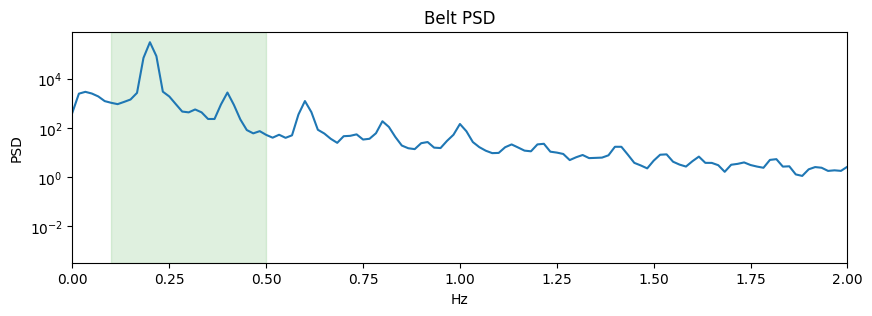

In [4]:
BREATH_COL = 'Arb2'  # Arb2 = chest belt (smooth ~5s waves); Arb1 = HR (squarish)

belt_t = belt['t'].to_numpy()
belt_x = belt[BREATH_COL].to_numpy(dtype=float).copy()
belt_x -= belt_x.mean()

# Belt-derived BPM via FFT, just so we have a ground-truth number to chase.
f, Pxx = signal.welch(belt_x, fs=belt_fs, nperseg=int(belt_fs * 60))
band = (f >= 0.1) & (f <= 0.5)
f_peak = f[band][np.argmax(Pxx[band])]
print(f'belt peak frequency: {f_peak:.3f} Hz  →  {f_peak * 60:.2f} BPM  (expected ≈ 12)')

plt.figure(figsize=(10, 3))
plt.semilogy(f, Pxx); plt.axvspan(0.1, 0.5, alpha=0.15, color='C2')
plt.xlim(0, 2); plt.xlabel('Hz'); plt.ylabel('PSD'); plt.title('Belt PSD');

## 2. Load and parse CSI

Each CSI row has a `CSI_DATA` field that looks like `"[110 96 6 0 0 0 ... ]"` — a list of signed bytes. The ESP-IDF convention is **interleaved imag/real pairs per subcarrier**: byte 0 = imag(sc0), byte 1 = real(sc0), byte 2 = imag(sc1), byte 3 = real(sc1), …

For a 20 MHz HT20 link there are 64 subcarriers → 128 bytes. We compute amplitude per subcarrier as `sqrt(real² + imag²)`. We use `real_timestamp` (Unix seconds) as the time axis.

In [5]:
csi_raw = pd.read_csv(CSI_PATH)
print(f'csi rows: {len(csi_raw)}')
print(f'duration: {csi_raw["real_timestamp"].iloc[-1] - csi_raw["real_timestamp"].iloc[0]:.1f} s')
csi_raw.head(2)

csi rows: 30230
duration: 300.0 s


,type,role,mac,rssi,rate,sig_mode,mcs,bandwidth,smoothing,not_sounding,...,secondary_channel,local_timestamp,ant,sig_len,rx_state,real_time_set,real_timestamp,len,CSI_DATA,timestamp
0,CSI_DATA,STA,E8:31:CD:E7:71:CD,-45,11,1,7,1,1,1,...,1,64689631,0,110,0,0,64.860,384,[110 96 6 0 0 0 0 0 0 0 0 0 12 -20 13 -21 14 -...,1.717503e+09
1,CSI_DATA,STA,E8:31:CD:E7:71:CD,-45,11,1,7,1,1,1,...,1,64693020,0,110,0,0,64.865,384,[110 96 6 0 0 0 0 0 0 0 0 0 -22 -21 -22 -21 -2...,1.717503e+09


In [6]:
def parse_csi_bytes(s):
    # "[110 96 6 0 ... ]" -> int8 array. (np.fromstring is deprecated in NumPy 2.)
    return np.array(s.strip()[1:-1].split(), dtype=np.int8)

first = parse_csi_bytes(csi_raw['CSI_DATA'].iloc[0])
print(f'bytes per packet: {len(first)}  (expect 128 for HT20 / 64 subcarriers)')

byte_mat = np.stack([parse_csi_bytes(s) for s in csi_raw['CSI_DATA']])
imag = byte_mat[:, 0::2].astype(np.float32)
real = byte_mat[:, 1::2].astype(np.float32)
amp  = np.sqrt(real ** 2 + imag ** 2)   # shape: (n_packets, 64)
t_csi = csi_raw['real_timestamp'].to_numpy(dtype=float).copy()
t_csi -= t_csi[0]

print(f'amp shape: {amp.shape}  duration: {t_csi[-1]:.1f}s  median fs: {1/np.median(np.diff(t_csi)):.1f} Hz')

bytes per packet: 128  (expect 128 for HT20 / 64 subcarriers)


amp shape: (30230, 64)  duration: 300.0s  median fs: 111.1 Hz


active subcarriers: 52 / 64  (documented HT20 data subcarriers)


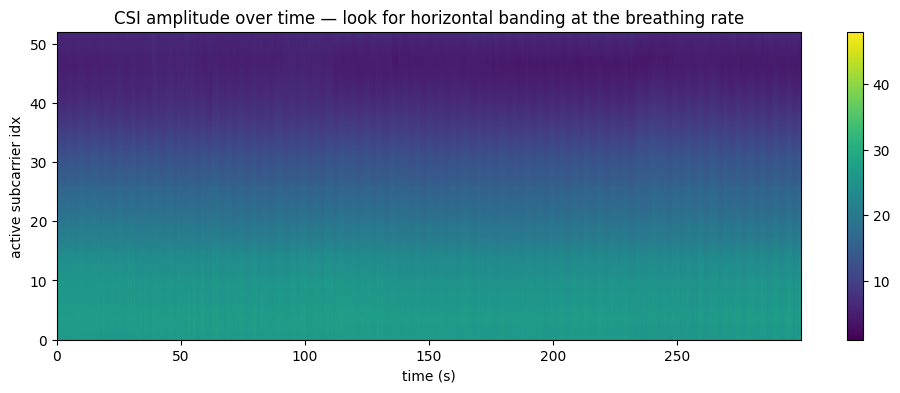

In [7]:
# Drop guard / DC-null / pilot subcarriers. The dataset authors document
# data subcarriers as indices [6:32] + [33:59] = 52 subcarriers (matches
# 802.11n HT20). This is more defensible than filtering by variance.
data_idx = np.r_[6:32, 33:59]
active = np.zeros(amp.shape[1], dtype=bool)
active[data_idx] = True
print(f'active subcarriers: {active.sum()} / {amp.shape[1]}  (documented HT20 data subcarriers)')

plt.figure(figsize=(12, 4))
plt.imshow(amp[:, active].T, aspect='auto', origin='lower',
           extent=[t_csi[0], t_csi[-1], 0, active.sum()])
plt.xlabel('time (s)'); plt.ylabel('active subcarrier idx')
plt.title('CSI amplitude over time — look for horizontal banding at the breathing rate')
plt.colorbar();

## 3. Resample CSI onto a uniform grid

ESP32 CSI packet times are jittery — the median rate is around 100 Hz but individual gaps vary. FFTs assume uniform sampling, so we interpolate each subcarrier onto a regular grid. We pick a target rate well above 2× the breathing band (Nyquist), e.g. 20 Hz.

In [8]:
FS = 20.0  # Hz, target uniform rate
t_grid = np.arange(t_csi[0], t_csi[-1], 1.0 / FS)
amp_u = np.stack([np.interp(t_grid, t_csi, amp[:, k]) for k in range(amp.shape[1])], axis=1)
amp_u = amp_u[:, active]
print(f'resampled: {amp_u.shape}  ({len(t_grid)} samples @ {FS} Hz = {len(t_grid)/FS:.1f}s)')

resampled: (6000, 52)  (6000 samples @ 20.0 Hz = 300.0s)


## 4. Detrend + bandpass each subcarrier

Breathing is 0.1–0.5 Hz (6–30 BPM). A 4th-order Butterworth bandpass kills the slow drift and the higher-frequency junk in one shot. Filtfilt is zero-phase so peaks don't shift.

In [9]:
def bandpass(x, fs, lo, hi, order=4):
    sos = signal.butter(order, [lo, hi], btype='band', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, x, axis=0)

amp_d = signal.detrend(amp_u, axis=0)
amp_b = bandpass(amp_d, FS, 0.1, 0.5)
print('filtered shape:', amp_b.shape)

filtered shape: (6000, 52)


## 5. Pick the best subcarriers and fuse

Not every subcarrier sees the chest motion equally well — multipath geometry decides. We rank subcarriers by their **in-band power** (variance after bandpass), keep the top quartile, then fuse them with PCA: the first principal component is the direction of largest shared variation, which should be the breathing component itself.

Sign of PC1 is arbitrary — we flip if needed so the trace looks intuitive.

In [10]:
in_band_power = amp_b.var(axis=0)
k = max(4, in_band_power.size // 4)
top = np.argsort(in_band_power)[-k:]
X = amp_b[:, top]
X = (X - X.mean(0)) / (X.std(0) + 1e-9)

# PC1 via SVD
U, S, Vt = np.linalg.svd(X, full_matrices=False)
fused = U[:, 0] * S[0]
if np.abs(fused.min()) > np.abs(fused.max()):
    fused = -fused
print(f'kept {k} subcarriers; PC1 explains {S[0]**2 / (S**2).sum():.1%} of variance')

kept 13 subcarriers; PC1 explains 94.0% of variance


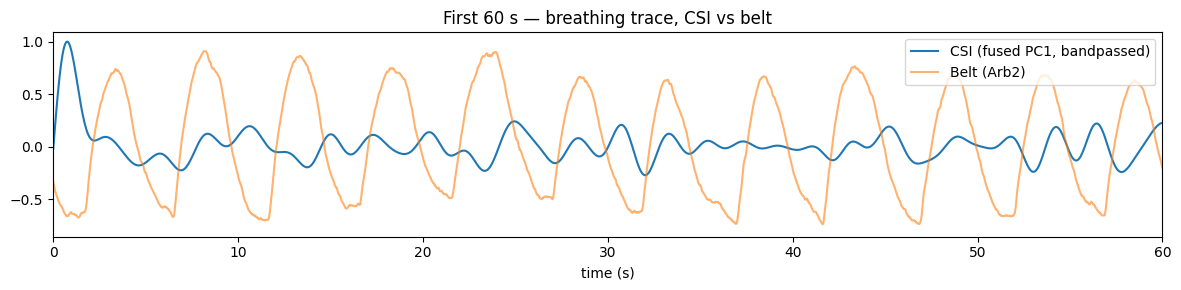

In [11]:
# Plot fused CSI breathing trace alongside the belt, both normalized.
def norm(x):
    x = x - x.mean()
    return x / (np.abs(x).max() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_grid, norm(fused), label='CSI (fused PC1, bandpassed)')
ax.plot(belt_t, norm(signal.detrend(belt_x)), alpha=0.6, label=f'Belt ({BREATH_COL})')
ax.set_xlim(t_grid[0], t_grid[0] + 60)  # first minute
ax.set_xlabel('time (s)'); ax.legend(); ax.set_title('First 60 s — breathing trace, CSI vs belt')
plt.tight_layout()

## 6. Estimate BPM from CSI and compare to belt

belt BPM:  12.00
CSI  BPM:  12.00
error:     0.00 BPM (target: <1)


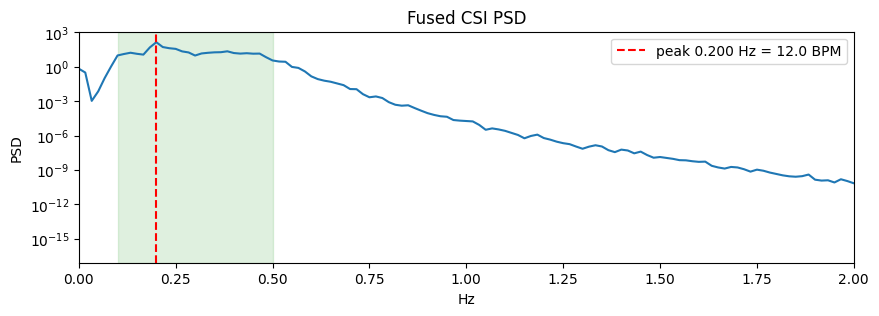

In [12]:
f, Pxx = signal.welch(fused, fs=FS, nperseg=int(FS * 60))
band = (f >= 0.1) & (f <= 0.5)
f_csi = f[band][np.argmax(Pxx[band])]
bpm_csi = f_csi * 60

print(f'belt BPM:  {f_peak * 60:.2f}')
print(f'CSI  BPM:  {bpm_csi:.2f}')
print(f'error:     {abs(bpm_csi - 12):.2f} BPM (target: <1)')

plt.figure(figsize=(10, 3))
plt.semilogy(f, Pxx); plt.axvspan(0.1, 0.5, alpha=0.15, color='C2')
plt.axvline(f_csi, color='r', ls='--', label=f'peak {f_csi:.3f} Hz = {bpm_csi:.1f} BPM')
plt.xlim(0, 2); plt.xlabel('Hz'); plt.ylabel('PSD'); plt.title('Fused CSI PSD'); plt.legend();

## What to do next

Depending on what comes out of this notebook:

- **CSI BPM lands within ±1 of 12 → great.** Move on: slide a 30-second window across the recording, get a BPM curve, and compare against a sliding belt BPM. That gives us a per-window error metric and is the first thing a learned model would try to beat.
- **CSI peak is near 12 but off by a few BPM.** Probably alignment / windowing — try a longer Welch segment, or remove the first/last seconds where the subject was settling.
- **No clear peak in the breathing band.** Inspect the heatmap from cell 4 — if there's no horizontal banding visible at all, the antenna geometry / distance might just be poor for this file. Try the apnoea CSVs in `Sleep Apnoa/` next; those subjects are paced too.
- **Peak is in the band but at the wrong frequency.** Check `BREATH_COL` — you may have picked the HR channel for ground truth.